


# Resumen — TP Integrador: Análisis de Clientes de Telecomunicaciones

> **Cuaderno explicativo del `TP_Integrador_Analisis_Clientes_Telecomunicaciones.ipynb`**
> Recorre, parte por parte, todo lo que se hizo en el integrador: **qué** se hizo, **por qué** se hizo así, y **qué teoría** hay detrás. Pensado para leer después de haber intentado el TP por tu cuenta.

Este integrador combina las tres grandes familias de Machine Learning que fuimos viendo en el módulo:

| Pregunta de negocio | Tipo de problema | Variable objetivo |
|---|---|---|
| ¿Cuánto facturará un cliente? | **Regresión** | `gasto_anual` (número continuo) |
| ¿Qué clientes podrían abandonar? | **Clasificación** | `abandono` (0 / 1) |
| ¿Existen perfiles distintos de clientes? | **Clustering** (no supervisado) | no hay — se descubre solo |

Pregunta	Qué métrica responde
¿Cuál acierta más en total?	                    Accuracy
¿Cuál detecta mejor a los que SÍ se van?	    Recall
¿Cuál se equivoca menos cuando dice "se va"?	Precision
¿Cuál tiene mejor equilibrio?	                F1


---
## Parte 0 — El dataset

`dataset_clientes_comunicaciones.csv`: 1000 clientes de una empresa de telecomunicaciones, con variables numéricas (`edad`, `antiguedad_meses`, `cargo_mensual`, `cantidad_servicios`, `consultas_soporte`, `reclamos_ultimo_anio`, `horas_uso_mensual`, `satisfaccion`), categóricas (`tipo_contrato`, `medio_pago`) y dos posibles variables objetivo (`gasto_anual` para regresión, `abandono` para clasificación).

Tres columnas tienen valores faltantes: `horas_uso_mensual` (12), `medio_pago` (10) y `satisfaccion` (18). Eso ya nos avisa que va a hacer falta una estrategia de imputación antes de entrenar cualquier modelo.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, silhouette_score)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('dataset_clientes_comunicaciones.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (1000, 13)


,id_cliente,edad,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,tipo_contrato,medio_pago,satisfaccion,gasto_anual,abandono
0,C1001,30,23,57300,1,6,3,45.3,Anual,Tarjeta,2.7,568000,1
1,C1002,49,42,128000,4,1,1,78.1,Anual,Transferencia,7.9,1549000,0
2,C1003,52,89,120100,3,0,1,55.4,Bianual,Debito automatico,7.8,1513000,0
3,C1004,34,21,48600,1,4,1,37.0,Anual,Efectivo,3.9,632000,1
4,C1005,26,4,67600,3,1,0,37.5,Mensual,Tarjeta,4.6,926000,0
5,C1006,54,79,144400,4,1,1,75.8,Anual,Efectivo,8.6,1708000,0
6,C1007,41,48,115400,3,7,3,89.2,Mensual,Debito automatico,1.0,1498000,1
7,C1008,28,5,81700,2,4,2,51.3,Mensual,Tarjeta,3.5,1149000,1
8,C1009,18,19,61800,1,5,1,38.7,Mensual,Tarjeta,5.6,862000,1
9,C1010,50,21,126300,3,3,1,93.0,Mensual,Debito automatico,8.5,1621000,0


**Línea por línea:** los imports son los mismos que ya usamos en TPs anteriores (regresión de Unidad 3, KNN de Unidad 5, árboles/bosques de Unidad 6, K-Means de Unidad 7), más cuatro nuevos que vamos a usar en la **Opción 2** de preprocesamiento (ver más abajo): `ColumnTransformer`, `Pipeline`, `SimpleImputer` y `OneHotEncoder`.

In [16]:
print('Valores faltantes:')
print(df.isnull().sum())
print()
print('Distribución de abandono:')
print(df['abandono'].value_counts())
print((df['abandono'].value_counts(normalize=True) * 100).round(1))

Valores faltantes:
id_cliente               0
edad                     0
antiguedad_meses         0
cargo_mensual            0
cantidad_servicios       0
consultas_soporte        0
reclamos_ultimo_anio     0
horas_uso_mensual       12
tipo_contrato            0
medio_pago              10
satisfaccion            18
gasto_anual              0
abandono                 0
dtype: int64

Distribución de abandono:
abandono
0    660
1    340
Name: count, dtype: int64
abandono
0    66.0
1    34.0
Name: proportion, dtype: float64


**Resultado clave:** `abandono` está en proporción 66 % (permanece) / 34 % (abandona). No es un desbalance extremo, pero alcanza para que el Accuracy solo no sea suficiente: un modelo que siempre dijera "permanece" ya acertaría 66 de cada 100 veces sin haber aprendido nada real. Por eso, más adelante, miramos también Precision/Recall/F1.

---
## Parte 1 — Por qué `id_cliente` no es un predictor

`id_cliente` (`C1001`, `C1002`, ...) es una etiqueta administrativa, no una característica del cliente. No tiene relación real con su comportamiento — y un cliente nuevo siempre va a tener un ID nunca antes visto, así que cualquier patrón que un modelo "aprendiera" a partir del ID sería pura coincidencia del orden de carga de los datos, no algo que generalice. Por eso lo excluimos de todos los conjuntos de predictoras (`X`) que armamos en este TP.

## Parte 2 — Imputación de valores faltantes: la decisión clave de este integrador

El enunciado pide una regla muy concreta: **la imputación debe ajustarse solo con datos de entrenamiento**. La razón es evitar *fuga de datos* (data leakage): si calculáramos la mediana o la moda usando también las filas de test, el modelo estaría "espiando" información estadística de datos que se supone nunca vio — y las métricas de evaluación dejarían de ser una medida honesta de qué tan bien generaliza.

Repasando el material del curso completo (Módulo 1 y Módulo 2), no hay ningún notebook previo que combine imputación + codificación de variables con más de 2 categorías + separación train/test en un solo flujo. Por eso este TP se resuelve con **dos opciones equivalentes**, para que compares:

- **Opción 1 (manual):** con `fillna()` para imputar (igual que en `Limpieza_de_Datos_con_Pandas.ipynb`, Módulo 1) y `pd.get_dummies()` para codificar (igual que en `TP_SQL_Pandas_Clinica_1.ipynb`, Módulo 1).
- **Opción 2 (Pipeline):** con `SimpleImputer` + `OneHotEncoder` dentro de un `ColumnTransformer`, todo envuelto en un `Pipeline` de scikit-learn — la sintaxis que el propio enunciado del TP sugiere ("Podés usar `ColumnTransformer` y `Pipeline`").

Ambas opciones están en el TP resuelto; acá las explicamos en detalle y comprobamos que dan el mismo resultado.


In [17]:
predictoras = ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
               'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual',
               'tipo_contrato', 'medio_pago', 'satisfaccion']
num_cols = ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
            'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion']
cat_cols = ['tipo_contrato', 'medio_pago']

X_reg = df[predictoras]
y_reg = df['gasto_anual']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)
print(X_reg_train.shape, X_reg_test.shape)

(800, 10) (200, 10)


**Línea por línea:**
- `predictoras`: todas las columnas que van a entrar al modelo, excepto `id_cliente` (no aporta información, sección anterior), `gasto_anual` (es el target de esta parte) y `abandono` (target de la Parte B, no corresponde acá).
- `num_cols` / `cat_cols`: separamos qué columnas son numéricas (se imputan con mediana) y cuáles categóricas (se imputan con moda y después se codifican).
- `train_test_split(..., test_size=0.20, random_state=42)`: 80 % train / 20 % test, semilla fija para reproducibilidad — el mismo patrón usado en todos los TPs anteriores del módulo.

In [18]:
def imputar_manual(X_train, X_test, num_cols, cat_cols):
    """Calcula mediana (numéricas) y moda (categóricas) SOLO con X_train,
    y aplica esos mismos valores a X_train y X_test."""
    X_train = X_train.copy(); X_test = X_test.copy()
    valores = {}
    for c in num_cols:
        mediana = X_train[c].median()
        valores[c] = mediana
        X_train[c] = X_train[c].fillna(mediana)
        X_test[c] = X_test[c].fillna(mediana)
    for c in cat_cols:
        moda = X_train[c].mode()[0]
        valores[c] = moda
        X_train[c] = X_train[c].fillna(moda)
        X_test[c] = X_test[c].fillna(moda)
    return X_train, X_test, valores

def codificar_manual(X_train, X_test, cat_cols):
    """One-Hot Encoding con pd.get_dummies, alineando columnas."""
    X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)
    return X_train_dum, X_test_dum

X_reg_train_i, X_reg_test_i, valores_imputacion_reg = imputar_manual(X_reg_train, X_reg_test, num_cols, cat_cols)
X_reg_train_final, X_reg_test_final = codificar_manual(X_reg_train_i, X_reg_test_i, cat_cols)

print('Valores aprendidos SOLO de train:', valores_imputacion_reg)
print('Columnas finales:', X_reg_train_final.columns.tolist())

Valores aprendidos SOLO de train: {'edad': np.float64(37.0), 'antiguedad_meses': np.float64(34.0), 'cargo_mensual': np.float64(105800.0), 'cantidad_servicios': np.float64(3.0), 'consultas_soporte': np.float64(3.0), 'reclamos_ultimo_anio': np.float64(1.0), 'horas_uso_mensual': np.float64(64.4), 'satisfaccion': np.float64(7.0), 'tipo_contrato': 'Anual', 'medio_pago': 'Debito automatico'}
Columnas finales: ['edad', 'antiguedad_meses', 'cargo_mensual', 'cantidad_servicios', 'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion', 'tipo_contrato_Bianual', 'tipo_contrato_Mensual', 'medio_pago_Efectivo', 'medio_pago_Tarjeta', 'medio_pago_Transferencia']


**Línea por línea — `imputar_manual`:**
- Para cada columna numérica: calcula `X_train[c].median()` — la mediana **solo** de train — y la guarda en el diccionario `valores` (la vamos a necesitar después, para el cliente nuevo). Aplica `.fillna(mediana)` tanto a train como a test, pero siempre con el mismo número calculado en train.
- Para cada columna categórica: lo mismo pero con `.mode()[0]` (la moda; `.mode()` devuelve una Serie porque podría haber empates, así que `[0]` toma el primer valor).

**Línea por línea — `codificar_manual`:**
- `pd.get_dummies(X, columns=cat_cols, drop_first=True)`: convierte cada columna categórica en columnas 0/1, una por cada categoría **menos una** (`drop_first=True` evita una columna redundante: si sabés que no es Bianual ni Mensual, ya sabés que es Anual).
- **El detalle importante:** llamamos a `get_dummies` por separado en train y test. Si alguna categoría rara apareciera solo en test, generaría una columna que no existe en train (o viceversa) — por eso `X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)` fuerza a que test tenga *exactamente* las mismas columnas que train, rellenando con 0 las que falten. Es un bug clásico al usar `get_dummies` con conjuntos separados si no se hace este último paso.


In [19]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_reg_train_final, y_reg_train)

y_reg_pred = modelo_reg.predict(X_reg_test_final)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = mse ** 0.5
r2 = modelo_reg.score(X_reg_test_final, y_reg_test)

print(f'MAE  : {mae:,.2f}')
print(f'MSE  : {mse:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 72,478.79
MSE  : 8,549,179,138.68
RMSE : 92,461.77
R2   : 0.9504


### Interpretando las métricas de regresión

- **MAE = $72.479**: en promedio, la predicción se equivoca por unos $72.479 (misma unidad que `gasto_anual`, fácil de interpretar).
- **RMSE = $92.462**: al elevar los errores al cuadrado antes de promediar, penaliza más los errores grandes. Que RMSE > MAE nos dice que hay algunos clientes con errores bastante más grandes que el promedio.
- **R² = 0.9504**: el modelo explica ~95 % de la variabilidad de `gasto_anual`. Es un ajuste muy bueno.

**¿Por qué no usamos Accuracy acá?** Porque Accuracy mide aciertos/errores entre *categorías discretas* ("¿acertó la clase o no?"). `gasto_anual` es un número continuo — no tiene sentido preguntar si el modelo "acertó" un valor exacto, sino **cuánto** se alejó del valor real. Por eso, en regresión, siempre se usan métricas de distancia (MAE/MSE/RMSE) o de varianza explicada (R²).


---
## Parte 3 — La Opción 2: `ColumnTransformer` + `Pipeline`

Esta es la forma "profesional" de resolver exactamente el mismo problema que la Opción 1, pero de manera automática: en vez de calcular manualmente medianas/modas y aplicar `fillna`/`get_dummies` en pasos sueltos (con el riesgo de olvidarse de algo, como el `reindex` de la sección anterior), encapsulamos **todo el preprocesamiento** en un solo objeto.

### ¿Qué hace cada pieza?

- **`SimpleImputer(strategy='median')`**: el equivalente de `X_train[c].median()` + `fillna()`, pero como un objeto que se `fit()` (aprende el valor) y después se `transform()` (lo aplica) — el mismo patrón `fit`/`transform` que ya conocemos de `StandardScaler`.
- **`OneHotEncoder(drop='first', handle_unknown='ignore')`**: el equivalente de `pd.get_dummies(drop_first=True)`, pero resuelve automáticamente el problema del "reindex": `handle_unknown='ignore'` le dice que, si aparece una categoría nunca vista en entrenamiento, simplemente ponga todos ceros en vez de romperse.
- **`ColumnTransformer`**: aplica una transformación distinta según el **tipo de columna** — el pipeline numérico (`SimpleImputer` de mediana) a `num_cols`, y el pipeline categórico (`SimpleImputer` de moda + `OneHotEncoder`) a `cat_cols` — todo en paralelo, y devuelve todo junto.
- **`Pipeline` final**: encadena el `ColumnTransformer` con el modelo (`LinearRegression`). Al llamar `.fit(X_train, y_train)`, primero el preprocesador aprende (con `X_train`) y transforma, y recién después se entrena el modelo con esos datos ya preprocesados. Al llamar `.predict(X_test)`, aplica automáticamente el mismo preprocesamiento aprendido — sin que tengamos que acordarnos de repetir cada paso a mano.


In [20]:
preprocesador_reg = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]), cat_cols)
])

modelo_reg_pipeline = Pipeline([
    ('preprocesamiento', preprocesador_reg),
    ('regresor', LinearRegression())
])

# Entrenamos directamente sobre X_reg_train "crudo" (con nulos y texto incluidos)
modelo_reg_pipeline.fit(X_reg_train, y_reg_train)
y_reg_pred_pipeline = modelo_reg_pipeline.predict(X_reg_test)

r2_pipeline = modelo_reg_pipeline.score(X_reg_test, y_reg_test)
print('R² (Pipeline):', round(r2_pipeline, 4))
print('¿Predicciones idénticas a la Opción 1?', np.allclose(y_reg_pred, y_reg_pred_pipeline))

R² (Pipeline): 0.9504
¿Predicciones idénticas a la Opción 1? True


**Resultado:** ambas opciones dan **exactamente el mismo R² (0.9504)** y las mismas predicciones — es matemáticamente la misma operación, solo cambia *cómo* se escribe el código. La ventaja de la Opción 2 es que es menos propensa a errores manuales (como olvidarse el `reindex`) y es el estándar más usado en proyectos reales de scikit-learn, especialmente cuando el preprocesamiento se vuelve más complejo.

---
## Parte 4 — Clasificación: ¿qué clientes podrían abandonar?

### 4.1 Data Leakage con `gasto_anual`

Antes de armar el modelo de clasificación hay que resolver una trampa: `gasto_anual` está fuertemente relacionado con `abandono` (un cliente que se va a mitad de año factura menos), pero esa relación es **al revés** de lo que necesitamos: `gasto_anual` es una *consecuencia* del abandono, no una señal previa que nos permita anticiparlo. En el momento real en que queremos predecir si un cliente va a abandonar (para poder actuar a tiempo), todavía no conocemos su facturación final del año — así que no podemos usarla como predictor. Usarla igual sería **fuga de información**: el modelo parecería funcionar muy bien en la evaluación, pero de una forma que no se puede replicar en un caso de uso real.

Por la misma razón, excluimos `id_cliente` (sección 1) y `abandono` (es el propio target).


In [21]:
X_clf = df[predictoras]
y_clf = df['abandono']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

X_clf_train_i, X_clf_test_i, valores_imputacion_clf = imputar_manual(X_clf_train, X_clf_test, num_cols, cat_cols)
X_clf_train_final, X_clf_test_final = codificar_manual(X_clf_train_i, X_clf_test_i, cat_cols)

print('Proporción de abandono en train:', y_clf_train.mean().round(3))
print('Proporción de abandono en test :', y_clf_test.mean().round(3))

Proporción de abandono en train: 0.34
Proporción de abandono en test : 0.34


**La novedad acá es `stratify=y`:** además de fijar `random_state=42`, le pedimos a `train_test_split` que mantenga la misma proporción de `abandono` (34 %) tanto en train como en test. Sin `stratify`, por puro azar podríamos terminar con una proporción bastante distinta en cada conjunto, lo que distorsionaría la evaluación — especialmente relevante porque las clases no están perfectamente balanceadas.

In [22]:
modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_clf_train_final, y_clf_train)
pred_log = modelo_log.predict(X_clf_test_final)

print('Accuracy :', round(accuracy_score(y_clf_test, pred_log), 4))
print('Precision:', round(precision_score(y_clf_test, pred_log), 4))
print('Recall   :', round(recall_score(y_clf_test, pred_log), 4))
print('F1       :', round(f1_score(y_clf_test, pred_log), 4))

cm_log = confusion_matrix(y_clf_test, pred_log)
print('\nMatriz de confusión:\n', cm_log)

Accuracy : 0.79
Precision: 0.6711
Recall   : 0.75
F1       : 0.7083

Matriz de confusión:
 [[107  25]
 [ 17  51]]


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Leyendo la matriz de confusión

Con 200 clientes de prueba (68 que realmente abandonan, 132 que permanecen):

- **51** abandonos reales detectados correctamente (verdaderos positivos).
- **17** clientes que abandonaron pero el modelo predijo "permanece" (falsos negativos) — el error más costoso para el negocio: son clientes en riesgo que *no* vamos a detectar.
- El **Recall** de la clase `abandono=1` es `51 / (51 + 17) = 0.75`: el modelo detecta 3 de cada 4 clientes que realmente van a abandonar.

El **Accuracy** (0.79) no distingue este detalle — promedia aciertos de ambas clases por igual, por eso conviene mirar también Precision/Recall/F1 cuando las clases están desbalanceadas (Parte 0).


---
## Parte 5 — KNN: escalado y elección de `k`

KNN necesita escalar las variables por el mismo motivo que vimos con K-Means en la Unidad 7: clasifica según distancias, y sin escalar, `cargo_mensual` (miles) dominaría el cálculo frente a `satisfaccion` (1 a 10).

Para elegir `k` sin "espiar" el conjunto de prueba, usamos el mismo patrón que en el TP explicativo de KNN (Unidad 5): `Pipeline(StandardScaler + KNN)` + `GridSearchCV` con validación cruzada (`cv=5`), evaluado **solo** sobre `X_clf_train_final`.


In [23]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {'knn__n_neighbors': [3, 5, 7, 9, 11]}

grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_clf_train_final, y_clf_train)

print('Mejor k:', grid_knn.best_params_['knn__n_neighbors'])
print('Accuracy promedio (CV):', round(grid_knn.best_score_, 4))

pred_knn = grid_knn.predict(X_clf_test_final)
print('Accuracy en test:', round(accuracy_score(y_clf_test, pred_knn), 4))
print('Recall en test  :', round(recall_score(y_clf_test, pred_knn), 4))

Mejor k: 5
Accuracy promedio (CV): 0.8025
Accuracy en test: 0.745
Recall en test  : 0.7059


**Por qué `cv=5` y no simplemente probar cada `k` una vez contra `X_clf_test`:** si eligiéramos `k` mirando directamente el resultado en test, estaríamos "ajustando" una decisión (el hiperparámetro `k`) usando el mismo conjunto que después usamos para *reportar* qué tan bueno es el modelo — el resultado dejaría de ser una medida honesta. Con validación cruzada, `X_train` se divide en 5 partes, se entrena 5 veces (4 partes para entrenar, 1 para validar, rotando), y se promedia — todo sin tocar `X_test` en ningún momento de la elección. Recién al final, `grid_knn.predict(X_clf_test_final)` usa el conjunto de prueba, una única vez, para la medición final.

**Resultado:** k=5 fue el mejor, con Accuracy en test de 0.745 — más bajo que la Regresión Logística (0.79).

---
## Parte 6 — Árbol de Decisión y overfitting

Entrenamos un árbol sin límite de profundidad, y después exploramos qué pasa al controlar `max_depth`.


Profundidad sin límite: 17
Accuracy en test: 0.695


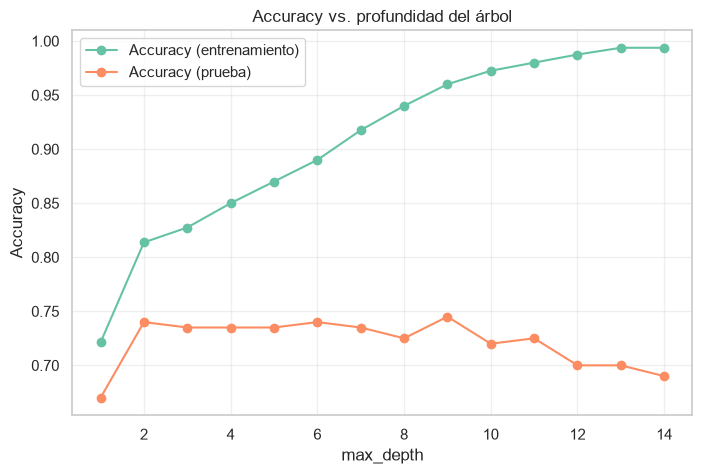

In [24]:
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_clf_train_final, y_clf_train)
pred_arbol = arbol.predict(X_clf_test_final)

print('Profundidad sin límite:', arbol.get_depth())
print('Accuracy en test:', round(accuracy_score(y_clf_test, pred_arbol), 4))

profundidades = range(1, 15)
acc_train_list, acc_test_list = [], []
for p in profundidades:
    a = DecisionTreeClassifier(max_depth=p, random_state=42)
    a.fit(X_clf_train_final, y_clf_train)
    acc_train_list.append(accuracy_score(y_clf_train, a.predict(X_clf_train_final)))
    acc_test_list.append(accuracy_score(y_clf_test, a.predict(X_clf_test_final)))

plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), acc_train_list, marker='o', label='Accuracy (entrenamiento)')
plt.plot(list(profundidades), acc_test_list, marker='o', label='Accuracy (prueba)')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Accuracy vs. profundidad del árbol')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Leyendo el gráfico: la firma del overfitting

Sin límite, el árbol creció a **17 niveles** y logró apenas **0.695** de Accuracy en test — peor que la Regresión Logística (0.79) y que el KNN (0.745), a pesar de ser mucho más "complejo". El gráfico explica por qué:

- La curva de **entrenamiento** sube casi sin parar con la profundidad, acercándose a ~0.99.
- La curva de **prueba** sube al principio, llega a un máximo alrededor de `max_depth` 6-9 (~0.74), y después **empieza a bajar** (hasta 0.69 en profundidad 14).

Esa brecha creciente entre ambas curvas es exactamente **overfitting**: a partir de cierta profundidad, el árbol deja de aprender el patrón general y empieza a memorizar detalles específicos (ruido) del conjunto de entrenamiento — mejora en datos ya vistos, pero empeora en datos nuevos. Por eso, **un árbol más complejo no necesariamente generaliza mejor**: acá, de hecho, generaliza peor.


---
## Parte 7 — Random Forest y comparación final

El Random Forest ataca justamente el problema de overfitting de un árbol individual, promediando muchos árboles entrenados con variaciones aleatorias de los datos (bagging) y de las variables consideradas en cada división — la misma idea que vimos en detalle en la Unidad 6.


In [25]:
bosque = RandomForestClassifier(n_estimators=100, random_state=42)
bosque.fit(X_clf_train_final, y_clf_train)
pred_bosque = bosque.predict(X_clf_test_final)

comparacion = pd.DataFrame({
    'Regresión Logística': [accuracy_score(y_clf_test, pred_log), precision_score(y_clf_test, pred_log),
                             recall_score(y_clf_test, pred_log), f1_score(y_clf_test, pred_log)],
    'KNN':                 [accuracy_score(y_clf_test, pred_knn), precision_score(y_clf_test, pred_knn),
                             recall_score(y_clf_test, pred_knn), f1_score(y_clf_test, pred_knn)],
    'Árbol de Decisión':   [accuracy_score(y_clf_test, pred_arbol), precision_score(y_clf_test, pred_arbol),
                             recall_score(y_clf_test, pred_arbol), f1_score(y_clf_test, pred_arbol)],
    'Random Forest':       [accuracy_score(y_clf_test, pred_bosque), precision_score(y_clf_test, pred_bosque),
                             recall_score(y_clf_test, pred_bosque), f1_score(y_clf_test, pred_bosque)],
}, index=['Accuracy', 'Precision', 'Recall', 'F1']).T.round(4)

comparacion

,Accuracy,Precision,Recall,F1
Regresión Logística,0.790,0.6711,0.7500,0.7083
KNN,0.745,0.6076,0.7059,0.6531
Árbol de Decisión,0.695,0.5432,0.6471,0.5906
Random Forest,0.755,0.6267,0.6912,0.6573


### ¿Cómo se elige "el mejor modelo"?

La tabla no se lee sola — primero hay que decidir qué error importa más para el negocio. Acá los cuatro indicadores coinciden en la **Regresión Logística** (mayor Accuracy, Precision, Recall y F1), así que la elección es clara. Pero conceptualmente, si tuviéramos que priorizar una sola métrica para este problema, sería el **Recall** de la clase `abandono=1`: nos interesa sobre todo minimizar los falsos negativos (clientes que se van y no detectamos), porque no detectar un abandono suele costarle más a la empresa que contactar de más a un cliente que en realidad iba a quedarse.

**No existe un algoritmo que sea siempre el mejor.** Acá ganó el modelo más simple (Regresión Logística); en otro dataset, con relaciones más no lineales, podría ganar un Random Forest. Por eso conviene comparar varios modelos en cada problema concreto, en vez de asumir de antemano cuál va a funcionar mejor.


---
## Parte 8 — Clustering: ¿existen perfiles de clientes?

Repetimos el flujo completo de K-Means que vimos en detalle en la Unidad 7 (escalado → elegir K con Elbow + Silhouette → entrenar → interpretar perfiles), esta vez con variables ligadas a la relación cliente-empresa: `antiguedad_meses`, `cargo_mensual`, `cantidad_servicios`, `consultas_soporte`, `reclamos_ultimo_anio`, `horas_uso_mensual`, `satisfaccion` (sin `id_cliente`, `gasto_anual` ni `abandono`, para no mezclar información de facturación/abandono en la segmentación de comportamiento).

Como no hay una variable `y` en clustering, no hay separación train/test: el escalado y la imputación se ajustan sobre **todo** el dataset de clustering.


In [26]:
vars_cluster = ['antiguedad_meses', 'cargo_mensual', 'cantidad_servicios',
                'consultas_soporte', 'reclamos_ultimo_anio', 'horas_uso_mensual', 'satisfaccion']
X_cluster = df[vars_cluster].copy()

for col in X_cluster.columns:
    if X_cluster[col].isnull().any():
        X_cluster[col] = X_cluster[col].fillna(X_cluster[col].median())

scaler_cluster = StandardScaler()
X_cluster_scaled = pd.DataFrame(scaler_cluster.fit_transform(X_cluster), columns=X_cluster.columns)

k_range = range(2, 9)
inercias, siluetas = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_cluster_scaled, labels_k))

pd.DataFrame({'k': list(k_range), 'inercia': inercias, 'silhouette': siluetas}).round(3)

,k,inercia,silhouette
0,2,4003.894,0.385
1,3,2954.903,0.390
2,4,2635.359,0.272
3,5,2490.832,0.228
4,6,2374.782,0.184
5,7,2231.531,0.162
6,8,2148.567,0.158


**Elegimos k=3**: el Silhouette Score máximo se da en k=3 (0.390), muy cerca de k=2 (0.385), y el Elbow muestra la caída más marcada de inercia también entre k=2 y k=3 (de 4003.9 a 2954.9), aplanándose después. Ambos criterios coinciden — no siempre pasa, pero acá simplifica la decisión.

In [27]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_cluster_scaled)
df['cluster'] = kmeans_final.labels_

perfil_clusters = df.groupby('cluster')[vars_cluster].mean().round(2)
perfil_clusters

,antiguedad_meses,cargo_mensual,cantidad_servicios,consultas_soporte,reclamos_ultimo_anio,horas_uso_mensual,satisfaccion
cluster,,,,,,,
0,61.25,129169.45,3.82,1.80,0.68,80.97,7.95
1,24.86,95620.28,2.39,6.14,4.03,62.45,4.11
2,10.67,68379.12,1.81,2.96,0.90,34.56,6.39


### Los tres perfiles que encontró el modelo, solo mirando comportamiento

| Cluster | n | Perfil |
|---|---|---|
| 0 | 491 | **Leales de alto valor**: antigüedad alta (~61 meses), muchos servicios, muchas horas de uso, satisfacción alta (7.95), pocos reclamos. |
| 1 | 212 | **En riesgo**: la satisfacción más baja (4.11), y por lejos los reclamos (4.03) y consultas de soporte (6.14) más altos. |
| 2 | 297 | **Nuevos de plan básico**: antigüedad muy baja (~11 meses), menos servicios y horas de uso, satisfacción intermedia. |

Igual que remarca la teoría de la Unidad 7: **el nombre de cada cluster es nuestra interpretación**, no algo que K-Means "sepa" — el algoritmo solo agrupó puntos matemáticamente cercanos; el significado de negocio ("en riesgo", "leales") lo ponemos nosotros al mirar los promedios de cada grupo.


---
## Parte 9 — Aplicando los tres modelos a un cliente nuevo

El cliente nuevo tiene que pasar por **exactamente el mismo preprocesamiento** que usamos para entrenar cada modelo — ni un paso distinto, ni valores de imputación recalculados.


In [ ]:
nuevo_cliente = {
    "edad": 34, "antiguedad_meses": 8, "cargo_mensual": 78000, "cantidad_servicios": 2,
    "consultas_soporte": 5, "reclamos_ultimo_anio": 3, "horas_uso_mensual": 65,
    "tipo_contrato": "Mensual", "medio_pago": "Tarjeta", "satisfaccion": 4
}
nuevo_df = pd.DataFrame([nuevo_cliente])

# 1. Regresión: mismos valores de imputación que en train, mismas columnas dummy
nuevo_reg = nuevo_df[predictoras].copy()
for c in num_cols + cat_cols:
    nuevo_reg[c] = nuevo_reg[c].fillna(valores_imputacion_reg[c])
nuevo_reg_dum = pd.get_dummies(nuevo_reg, columns=cat_cols).reindex(columns=X_reg_train_final.columns, fill_value=0)
gasto_estimado = modelo_reg.predict(nuevo_reg_dum)[0]

# 2. Clasificación con el modelo recomendado (Regresión Logística)
nuevo_clf = nuevo_df[predictoras].copy()
for c in num_cols + cat_cols:
    nuevo_clf[c] = nuevo_clf[c].fillna(valores_imputacion_clf[c])
nuevo_clf_dum = pd.get_dummies(nuevo_clf, columns=cat_cols).reindex(columns=X_clf_train_final.columns, fill_value=0)
pred_abandono = modelo_log.predict(nuevo_clf_dum)[0]
proba_abandono = modelo_log.predict_proba(nuevo_clf_dum)[0]

# 3. Cluster: mismo scaler que en el K-Means
nuevo_cluster_scaled = scaler_cluster.transform(nuevo_df[vars_cluster])
cluster_asignado = kmeans_final.predict(nuevo_cluster_scaled)[0]

print(f'Gasto anual estimado: ${gasto_estimado:,.0f}')
print(f'Predicción de abandono: {"ABANDONA" if pred_abandono == 1 else "PERMANECE"} (prob. abandonar: {proba_abandono[1]:.1%})')
print(f'Cluster asignado: {cluster_asignado}')

Gasto anual estimado: $1,045,337
Predicción de abandono: ABANDONA (prob. abandonar: 90.6%)
Cluster asignado: 1


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


: 

**Por qué reusamos `valores_imputacion_reg` / `valores_imputacion_clf` en vez de recalcular la mediana/moda:** ese cliente es UNO SOLO — no tiene sentido (ni sería válido) calcular una "mediana" a partir de un solo dato. Los valores de imputación que corresponden son los que el modelo ya aprendió de `X_train` durante el entrenamiento; el cliente nuevo se trata igual que cualquier fila de un futuro conjunto de prueba.

**El resultado coincide entre los tres modelos, entrenados de forma completamente independiente:** facturación estimada ~$1.045.000, probabilidad de abandono ~90.6 %, y asignado al cluster "en riesgo" (antigüedad baja, reclamos y consultas altos, satisfacción baja — coincide exactamente con el perfil de ese cliente). Que las tres herramientas, sin comunicarse entre sí, lleguen a la misma lectura del cliente, es una señal de que el diagnóstico es consistente.


---
## Cierre — Ideas para llevarse de este integrador

1. **El tipo de problema define todo lo demás**: qué algoritmo usar, qué métricas calcular, y cómo evaluar el resultado. Regresión → error numérico (MAE/RMSE/R²). Clasificación → aciertos por clase (Accuracy/Precision/Recall/F1). Clustering → cohesión/separación (Inercia/Silhouette).
2. **La fuga de datos (data leakage) tiene dos caras en este TP**: usar `gasto_anual` para predecir `abandono` (leakage temporal/causal), y ajustar el scaler o la imputación con datos de test (leakage estadístico). Ambas hacen que un modelo parezca mejor de lo que realmente es.
3. **Preprocesar "a mano" (fillna + get_dummies) y con `Pipeline`/`ColumnTransformer` son equivalentes** — lo comprobamos numéricamente en la Parte 3. La segunda opción es más robusta para proyectos más grandes, pero ambas son válidas.
4. **Un modelo más complejo no es automáticamente mejor**: el árbol sin límite (17 niveles) perdió contra la Regresión Logística por overfitting. Lo que importa es que generalice bien a datos nuevos, no que se ajuste perfecto a los datos de entrenamiento.
5. **Una métrica no es una conclusión.** "R²=0.95" o "Recall=0.75" son solo el punto de partida — hace falta traducirlos al problema real (¿$72.000 de error es mucho o poco para este negocio?) y reconocer las limitaciones (¿qué pasa con el 25 % de abandonos que no detectamos?) antes de recomendar una decisión.
